In [11]:
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [12]:
load_dotenv()

True

In [13]:
model = ChatGroq(model = "openai/gpt-oss-20b")

In [14]:
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage], add_messages]

In [15]:
def chat_node(state : ChatState):
        
    # Fetch user query
    messages = state['messages']
    
    # Send query to LLM
    response = model.invoke(messages)
    
    # Save response
    return {'messages':[response]}

In [16]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

graph.add_node("chat_node",chat_node)

graph.add_edge(START,"chat_node")
graph.add_edge("chat_node",END)

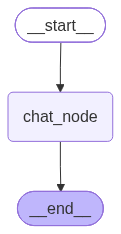

In [17]:
chatbot = graph.compile(checkpointer = checkpointer)
chatbot

In [18]:
# initial_state = {
#     "messages" : [HumanMessage(content = "What is the capital of India?")]
# }

# chatbot.invoke(initial_state)

In [19]:
thread_id = '1'

while True:
    
    user_query = input("Enter query: ")
    
    print("User : ",user_query)
    
    if user_query.strip().lower() in ["exit","quit","bye"]:
        break
    
    config = {'configurable':{'thread_id':thread_id}}
    
    response = chatbot.invoke({"messages":[HumanMessage(user_query)]}, config = config)
    
    print("AI :",response['messages'][-1].content)

User :  hi, my name is saurabh
AI : Hello Saurabh! How can I help you today?
User :  I am currenlty in 3rd year of my btech
AI : That’s great! 🎓  
What’s on your mind right now? Are you looking for help with:

- Coursework or project ideas?  
- Internship / placement prep?  
- Career paths after BTech?  
- Study strategies or time‑management tips?  

Let me know, and I’ll tailor my advice to your needs!
User :  i am trying to prep for internships right now
AI : ## 🚀 Internship Prep Playbook (BTech 3rd Year)

Below is a step‑by‑step roadmap that covers everything from polishing your résumé to acing the interview. Feel free to skip parts you’ve already nailed, or dive deeper where you need more help.

| Phase | What to Do | Tips & Resources |
|-------|------------|------------------|
| **1️⃣ Self‑Assessment** | • Identify *fields* (software dev, data science, embedded, product, etc.)<br>• List *skills* you’ve built (languages, frameworks, tools).<br>• Pinpoint *weak spots* (e.g., data st

In [ ]:
chatbot.get_state(config = config)